# Figure 12.

| Author  | Stanley A. Baronett  |
|---------|----------------------|
| Created |  03/04/2026          |
| Updated |  03/04/2026          |

Similar to Figure 1, except the upper panel only shows grid resolutions at $1024^2$, and the lower panel shows them in black along with $512^2$ in gray.

In [1]:
#===============================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.axes_grid1 import AxesGrid
import numpy as np
import pandas as pd

root = '..'
reses = [512, 1024]
res = reses[-1]
n_p = 'np1'
runs = {
    f'dust_particles/{n_p}': {
        'ls': 'dotted',
        'codes' : {
            'Athena':       'tab:green',
            'Athena++':     'tab:red',
            'Pencil':       'tab:blue',
            'PLUTO':        'tab:pink'
        }
    },
    'dust_fluid': {
        'ls': 'solid',
        'codes' : {
            'Athena++':     'tab:purple',
            'FARGO3D':      'tab:olive',
            'Idefix':       'tab:orange',
            'LA-COMPASS':   'tab:cyan',
            'PLUTO':        'tab:brown'
        }
    }
}

/tmp/ipykernel_27558/2296068901.py:50: RuntimeWarning: divide by zero encountered in log
  std = np.exp(np.std(np.log(key_stack), axis=0))
/home/stanley/miniconda3/envs/athena/lib/python3.11/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


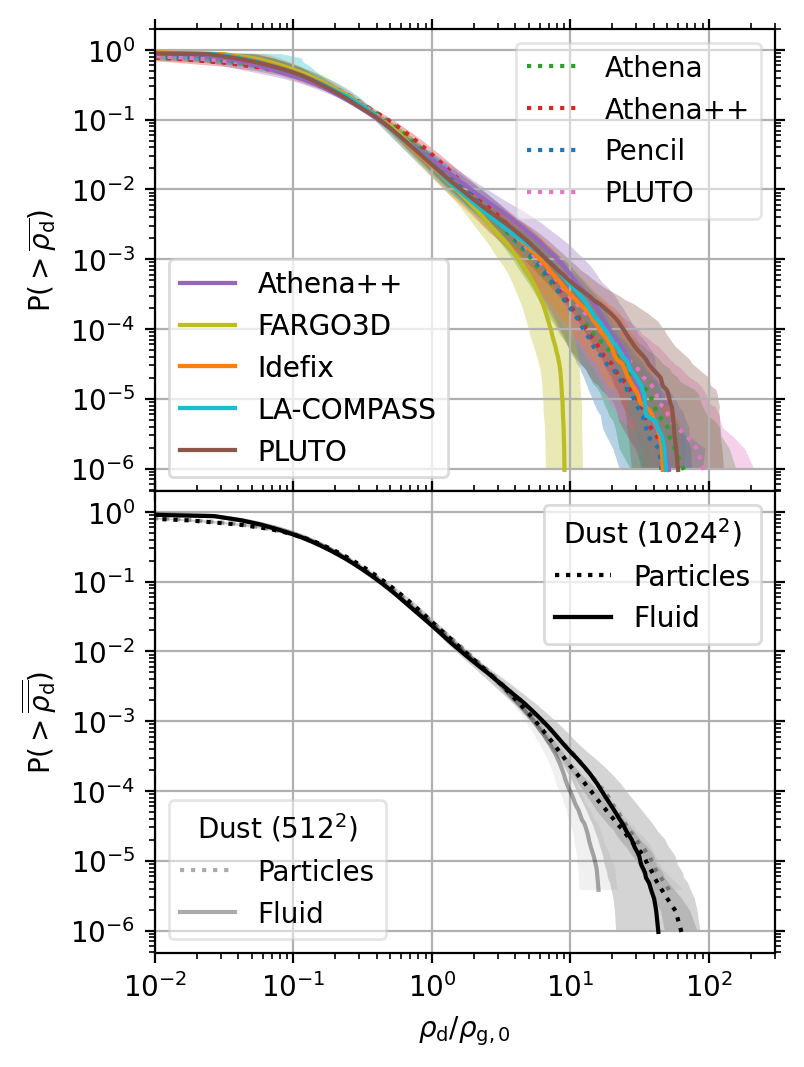

In [2]:
#===============================================================================
times = [20, 50, 100]  # [T]

# Plot
fig, axs = plt.subplots(nrows=2, sharex=True, figsize=(4, 6), dpi=200)
c_handles, ls_handles1, ls_handles2 = [], [], []
label = 'Particles'
loc = 'upper right'
for res in reses:
    indices = -np.unique(np.logspace(np.log2(res**2), 0, num=100, base=2,
                         dtype=int))
    for key, value in runs.items():
        if key == 'dust_fluid':
            label = 'Fluid'
            loc = 'lower left'
        key_stack, c_handles = [], []
        for code, color in value['codes'].items():
            path = f'{root}/{res}/src/{key}/{code}'
            rhods = []
            for i, time in enumerate(times):
                snapshot = np.load(f'{path}/{time}.npz')
                sort = np.sort(snapshot['rhod'], axis=None)
                rhods.append(sort)
            rhods = np.asarray(rhods)
            avgs = np.average(rhods, axis=0)
            cdf = np.linspace(1, 0, avgs.size, endpoint=False)
            log = np.log(np.clip(rhods, 1e-45, None))
            std_log = np.std(log, axis=0)
            stds = np.clip(np.exp(std_log), None, 3)
            cdf = np.take_along_axis(cdf, indices, 0)
            avgs = np.take_along_axis(avgs, indices, 0)
            stds = np.take_along_axis(stds, indices, 0)
            if res == 512:
                alpha = 0.33
                ls = value['ls']
                hatch = None
                c_handles.append(axs[0].plot([],[], c=color, label=code,
                                             ls=ls)[0])
            else:
                alpha = 1.0
                ls = 'dashed'
                axs[0].plot(avgs, cdf, alpha=alpha, c=color, ls=value['ls'])
                axs[0].fill_betweenx(cdf, avgs/stds, avgs*stds, alpha=alpha/3,
                                    color=color, ec=None)
            key_stack.append(avgs)
        if res == 512:
            axs[0].add_artist(axs[0].legend(framealpha=0.5, handles=c_handles, loc=loc))
        key_stack = np.asarray(key_stack)
        mean = np.mean(key_stack, axis=0)
        std = np.exp(np.std(np.log(key_stack), axis=0))
        axs[1].plot(mean, cdf, alpha=alpha, c='k', ls=value['ls'])
        axs[1].fill_betweenx(cdf, mean/std, mean*std, alpha=alpha/3,
                             color='tab:gray', ec=None)

# Custom legends
ls_handles1.append(axs[1].plot([], [], ':k', alpha=0.33, label='Particles')[0])
ls_handles1.append(axs[1].plot([], [], 'k', alpha=0.33, label='Fluid')[0])
axs[1].add_artist(axs[1].legend(framealpha=0.5, handles=ls_handles1,
                                loc='lower left', title=r'Dust ($512^2$)'))
ls_handles2.append(axs[1].plot([], [], ':k', label='Particles')[0])
ls_handles2.append(axs[1].plot([], [], 'k', label='Fluid')[0])
axs[1].add_artist(axs[1].legend(framealpha=0.5, handles=ls_handles2,
                                loc='upper right', title=r'Dust ($1024^2$)'))


# Format plots
for ax in axs:
    ax.grid()
    ax.minorticks_on()
    ax.set(xscale='log', yscale='log')
    ax.tick_params(axis='both', which='both', top=True, right=True)
axs[0].set(ylabel=r'P$(>\overline{\rho_\mathrm{d}})$')
axs[1].set(xlim=(1e-2, 3e2),
           xlabel=r'$\rho_\mathrm{d}/\rho_\mathrm{g,0}$',
           ylabel=r'P$(>\overline{\overline{\rho_\mathrm{d}}})$')
fig.subplots_adjust(hspace=0)